# Análisis Exploratorio: Mercado Eléctrico Español (Series Temporales)

## 1. Contexto y Objetivo
Este análisis audita el comportamiento del mercado eléctrico español entre 2014 y 2018,
utilizando datos horarios del operador del sistema (Red Eléctrica de España).
El dataset contiene múltiples métricas energéticas identificadas por ID — precio SPOT,
demanda real y generación por fuente — mezcladas en una estructura longitudinal que
requiere aislamiento previo de cada señal antes de cualquier análisis.

El objetivo es identificar los factores que determinan el precio de la energía,
con foco especial en la relación entre la generación renovable y el costo del mercado.

> **Orden de Mérito**: en el mercado eléctrico, las fuentes de energía se despachan
> de menor a mayor costo marginal. Las renovables (eólica, solar) tienen costo marginal
> casi cero, por lo que entran primero. Cuando generan mucho, desplazan fuentes más caras
> y el precio final del mercado baja. Esa es la hipótesis central que este análisis busca
> confirmar o refutar.

## 2. Resumen Ejecutivo
* **Tendencia de precios volátil**: el precio SPOT muestra alta variabilidad inter-anual,
  con períodos de precios bajos sostenidos que coinciden con alta generación renovable.
* **Demanda relativamente estable**: la demanda energética total no fluctúa tanto como
  el precio, lo que sugiere que la oferta (no el consumo) es el principal driver del precio.
* **El viento mueve el precio**: la generación eólica tiene correlación negativa con el
  precio SPOT — más viento produce energía más barata. Es la relación más fuerte del dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#configuracion inicial de librerias para graficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

#carga de dataset
data_path = "../data/raw/spain_energy_market.csv"
df_energia = pd.read_csv(data_path,parse_dates=["datetime"]) #parsear la columna de fecha
df_energia = df_energia.set_index("datetime") #poner fecha como indice para utilizar como eje temporal

print("Estructura temporal inicial:")
df_energia.info()
display(df_energia.head())


Estructura temporal inicial:
<class 'pandas.DataFrame'>
DatetimeIndex: 40212 entries, 2014-01-01 23:00:00 to 2018-12-31 23:00:00
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       40212 non-null  int64  
 1   name     34734 non-null  str    
 2   geoid    10956 non-null  float64
 3   geoname  10956 non-null  str    
 4   value    40212 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.8 MB


,id,name,geoid,geoname,value
datetime,,,,,
2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833
2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167
2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083
2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667
2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500


## Analisis de Metadatos y Diccionario de Variables
Inspección de las columnas categóricas (`geoname` y `name`) para identificar zonas geográficas involucradas y evaluar la viabilidad de reconstruir los nombres faltantes a través del `id`.

In [4]:
#que zonas existen y cuantos datos tienen?
print('Regiones Geograficas detectadas (geoname)')
print(df_energia['geoname'].value_counts(dropna=False))

#se puede usar el ID para rescatar los nombres?
print("Mapeo de ID vs Name")
#agrupar por id y contar valores unicos
mapeo_id_name = df_energia.groupby('id')['name'].unique()
print(mapeo_id_name)

Regiones Geograficas detectadas (geoname)
geoname
NaN         29256
España       3652
Francia      3652
Portugal     3652
Name: count, dtype: int64
Mapeo de ID vs Name
id
3           [Generación programada PBF Turbinación bombeo]
4                      [Generación programada PBF Nuclear]
9              [Generación programada PBF Ciclo combinado]
14          [Generación programada PBF Solar fotovoltaica]
17       [Generación programada PBF Gas Natural Cogener...
600      [Precio mercado SPOT Diario ESP, Precio mercad...
602       [Energía asignada en Mercado SPOT Diario España]
1117     [Rentas de congestión mecanismos implícitos di...
1118     [Rentas de congestión mecanismos implícitos di...
1119     [Rentas de congestión mecanismos implícitos di...
1120     [Rentas de congestión mecanismos implícitos di...
1293                                        [Demanda real]
1334     [Energía asignada en Mercado SPOT Diario Francia]
10064             [Generación programada PBF UGH + no UGH]
100

## Aislamiento de Señales Temporales Críticas
Filtrado transversal del dataset para extraer y separar las series temporales puras correspondientes al precio de mercado (España) y la demanda energética total, eliminando el ruido de métricas secundarias y fronterizas.

In [5]:
#extraer solo filas del precio de espana (ID 600 + nombre especifico)
df_precio = df_energia[(df_energia['id'] == 600) & (df_energia['name'] == 'Precio mercado SPOT Diario ESP')].copy()

#extraer solo las filas de la demanda real (id 1293)
df_demanda = df_energia[df_energia['id']== 1293].copy()

#aislar metadatos
df_precio = df_precio[['value']].rename(columns={'value': 'precio_spot'})
df_demanda = df_demanda[['value']].rename(columns={'value': 'demanda_mwh'})

print("Volumen de senales Aisladas")
print(f"Horas registradas de Precio: {len(df_precio)}")
print(f"Horas registradas de Demanda: {len(df_demanda)}")

print("\nVista previa: Precio spot:")
display(df_precio.head())

Volumen de senales Aisladas
Horas registradas de Precio: 1826
Horas registradas de Demanda: 1825

Vista previa: Precio spot:


,precio_spot
datetime,
2014-01-01 23:00:00,25.280833
2014-01-02 23:00:00,39.924167
2014-01-03 23:00:00,4.992083
2014-01-04 23:00:00,4.091667
2014-01-05 23:00:00,13.587500


## Visualizacion Macroscopica
Aplicacion de remuestreo temporal (agrupacion diaria y mensual) para observar el comportamiento

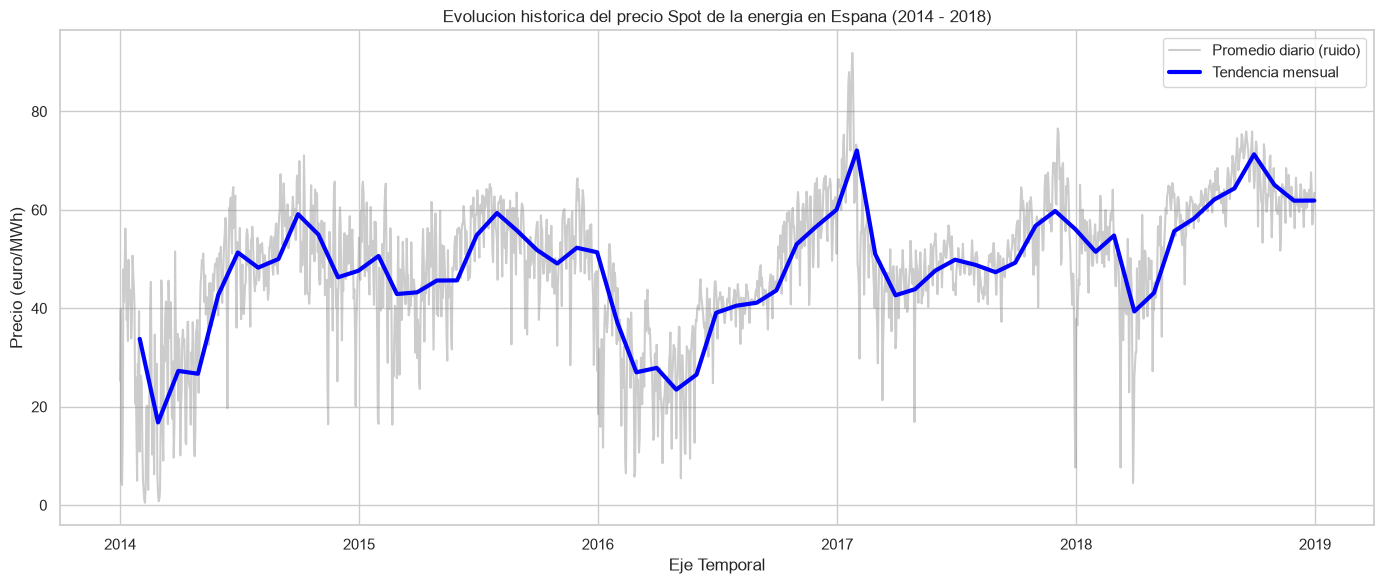

In [6]:
#convertir ruido horario en promedios diarios y mensuales
precio_diario = df_precio['precio_spot'].resample('D').mean()
precio_mensual = df_precio['precio_spot'].resample('ME').mean()

#grafico
plt.figure(figsize=(14, 6))

#pulso diario
plt.plot(precio_diario.index, precio_diario.values, color='gray', alpha=0.4, label='Promedio diario (ruido)')

#tendencia mensual
plt.plot(precio_mensual.index, precio_mensual.values, color='blue', linewidth=3, label='Tendencia mensual')

plt.title('Evolucion historica del precio Spot de la energia en Espana (2014 - 2018)')
plt.ylabel('Precio (euro/MWh)')
plt.xlabel('Eje Temporal')
plt.legend()
plt.tight_layout()
plt.show()

## Analisis Bivariado Temporal (Precio vs Demanda)
Sincronización de las señales macroscópicas de precio y demanda real para identificar la correlación gravitacional entre el consumo físico y el impacto financiero en el mercado SPOT.

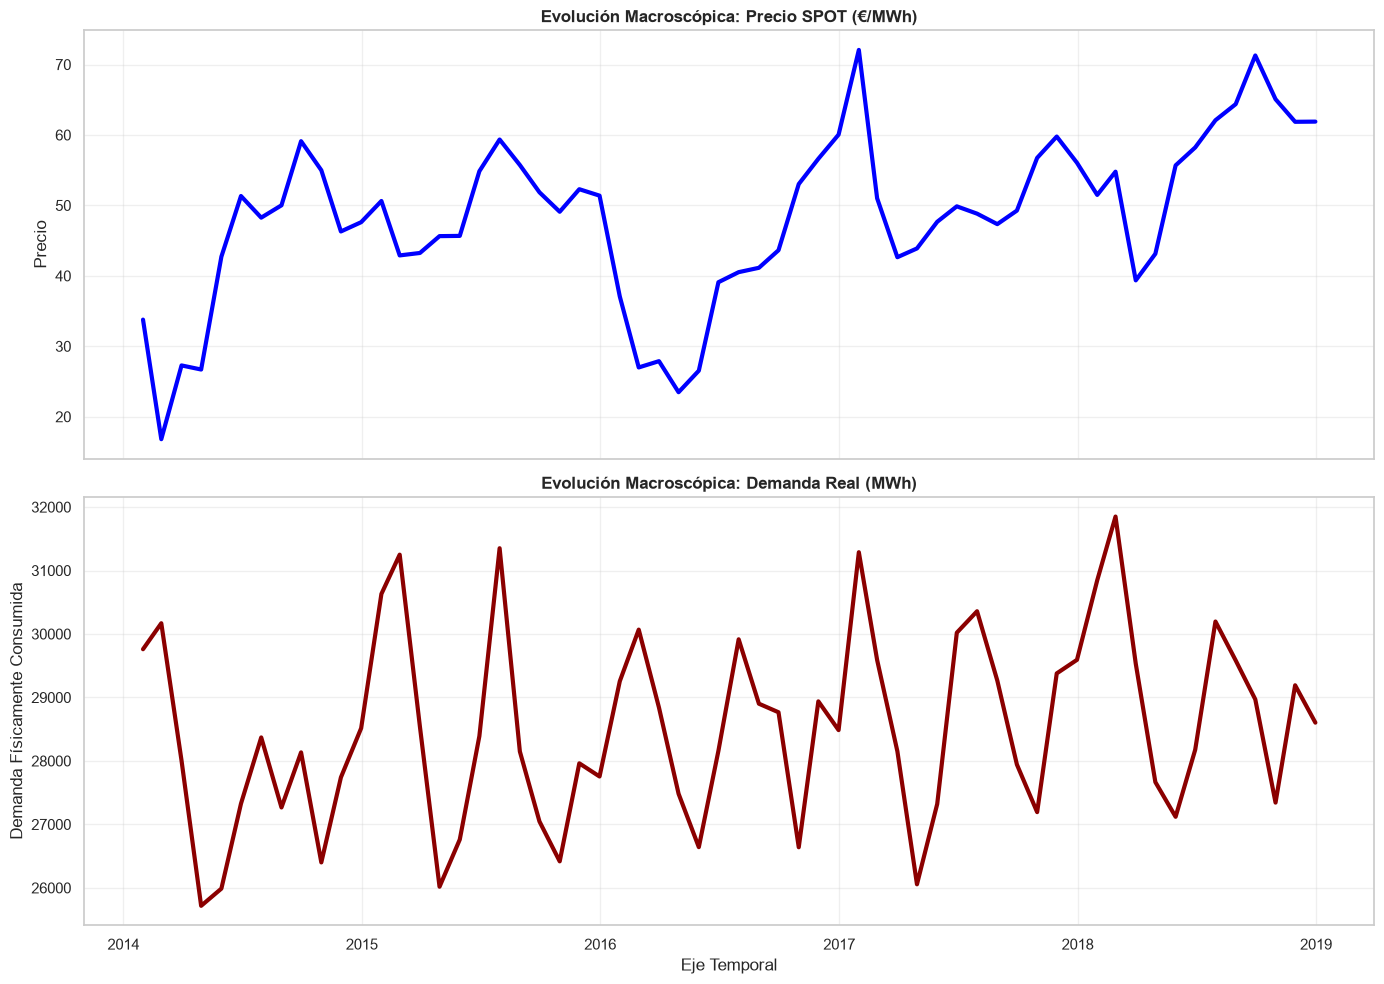

In [7]:
#remuestreo mensual de la demanda
demanda_mensual = df_demanda['demanda_mwh'].resample('ME').mean()

#arquitectura del grafico
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

#panel superior
ax1.plot(precio_mensual.index, precio_mensual.values, color='blue', linewidth=3)
ax1.set_title('Evolución Macroscópica: Precio SPOT (€/MWh)', fontweight='bold')
ax1.set_ylabel('Precio')
ax1.grid(True, alpha=0.3)

#panel inferior
ax2.plot(demanda_mensual.index, demanda_mensual.values, color='darkred', linewidth=3)
ax2.set_title('Evolución Macroscópica: Demanda Real (MWh)', fontweight='bold')
ax2.set_ylabel('Demanda Físicamente Consumida')
ax2.set_xlabel('Eje Temporal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Inyeccion del Factor Climatico
Aislamiento de la métrica de generación eólica para identificar el impacto del "Orden de Mérito" y la energía de costo marginal cero sobre los precios finales del mercado.

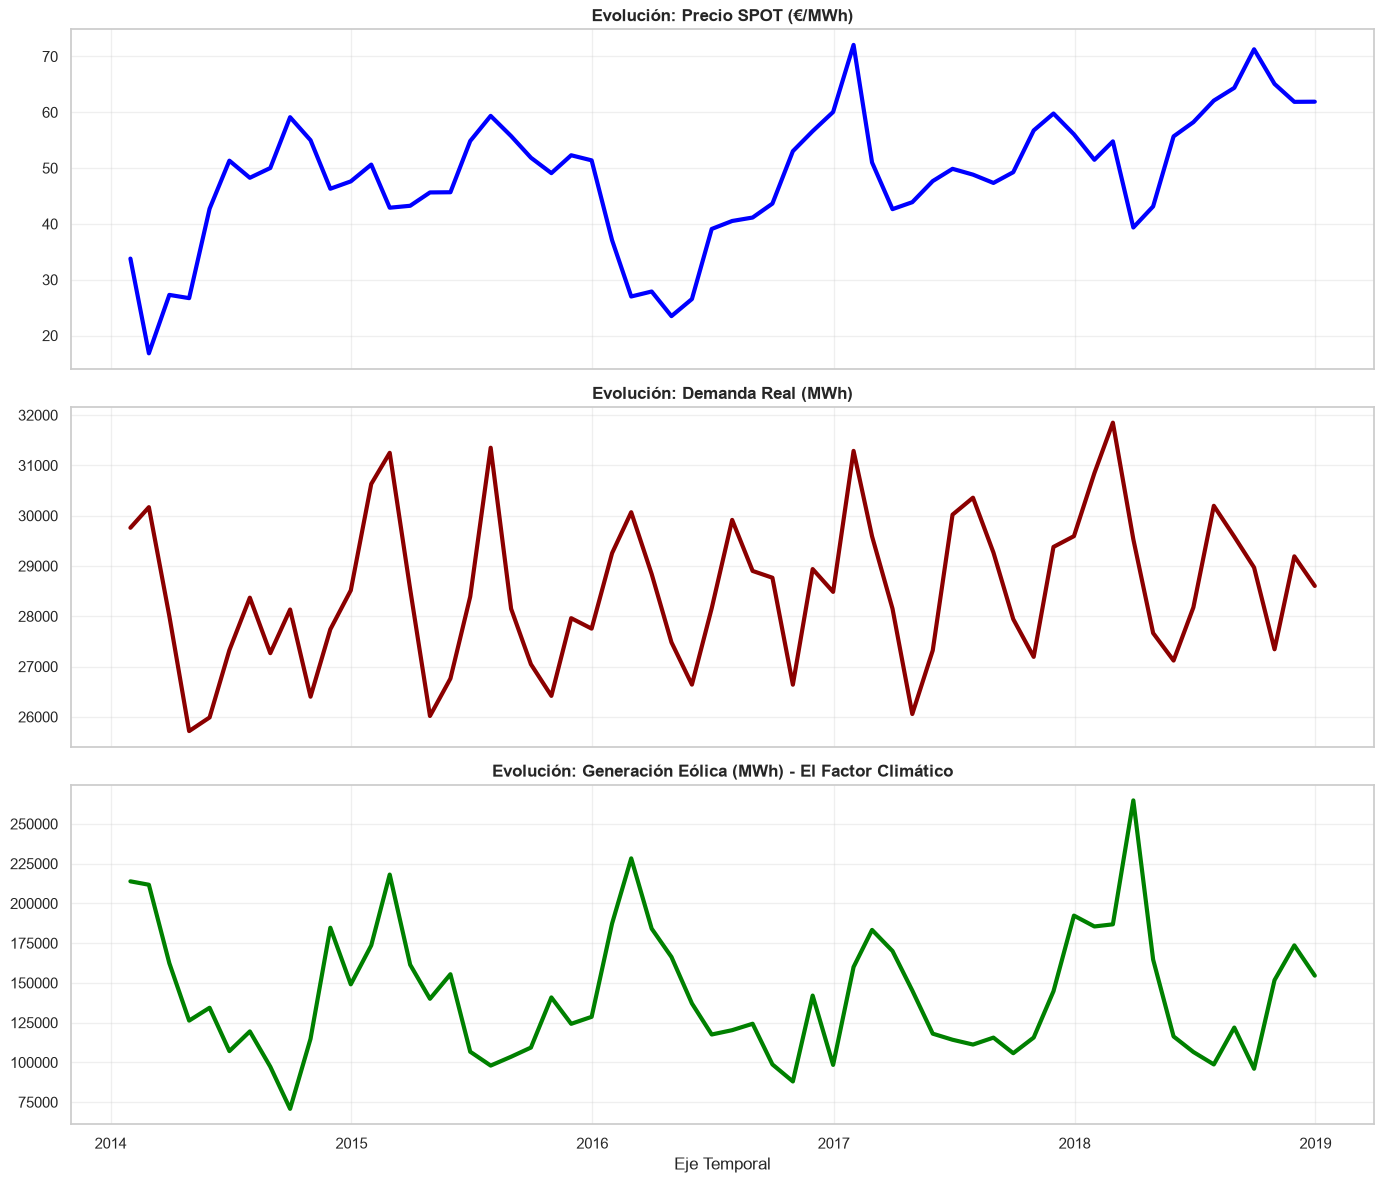

In [8]:
#aislamiento de la generacion eolica (ID 10073)
df_eolica = df_energia[df_energia['id'] == 10073].copy()
df_eolica = df_eolica[['value']].rename(columns={'value': 'generacion_eolica'})

#remuestreo mensual para alinear con los otros radares
eolica_mensual = df_eolica['generacion_eolica'].resample('ME').mean()

#arquitectura del grafico
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

#panel 1
ax1.plot(precio_mensual.index, precio_mensual.values, color='blue', linewidth=3)
ax1.set_title('Evolución: Precio SPOT (€/MWh)', fontweight='bold')
ax1.grid(True, alpha=0.3)

#panel 2
ax2.plot(demanda_mensual.index, demanda_mensual.values, color='darkred', linewidth=3)
ax2.set_title('Evolución: Demanda Real (MWh)', fontweight='bold')
ax2.grid(True, alpha=0.3)

#panel 3
ax3.plot(eolica_mensual.index, eolica_mensual.values, color='green', linewidth=3)
ax3.set_title('Evolución: Generación Eólica (MWh) - El Factor Climático', fontweight='bold')
ax3.set_xlabel('Eje Temporal')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Demostración Matemática: Correlación y Dispersión
Fusión de las señales temporales (remuestreo diario) en un único dataframe para calcular la matriz de Pearson y visualizar la relación inversa mediante un gráfico de dispersión con regresión lineal.

Matriz de correlacion de Pearson


,precio_spot,demanda_mwh,generacion_eolica
precio_spot,1.000000,0.310093,-0.499630
demanda_mwh,0.310093,1.000000,0.103858
generacion_eolica,-0.499630,0.103858,1.000000


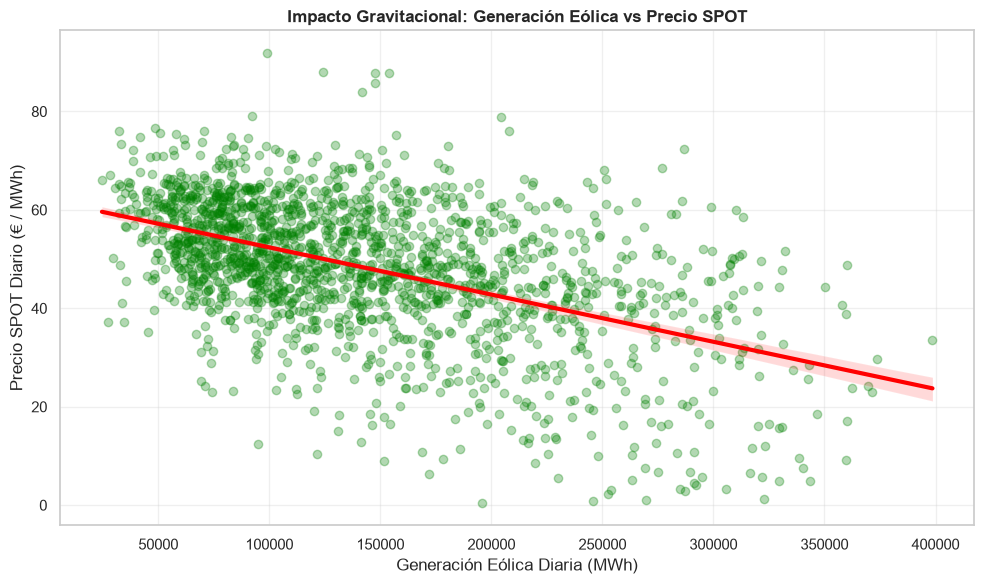

In [9]:
#demostracion matematica viento vs precio

#remuestreo diario
precio_D = df_precio['precio_spot'].resample('D').mean()
demanda_D = df_demanda['demanda_mwh'].resample('D').mean()
eolica_D = df_eolica['generacion_eolica'].resample('D').mean()

#fusion estructural
df_cruce = pd.concat([precio_D, demanda_D, eolica_D], axis=1).dropna()

#calculo de la matriz de correlacion de Pearson
correlacion = df_cruce.corr()
print("Matriz de correlacion de Pearson")
display(correlacion)

#arquitectura del grafico de dispersion
plt.figure(figsize=(10, 6))
sns.regplot(data=df_cruce, x='generacion_eolica', y='precio_spot', 
            scatter_kws={'alpha':0.3, 'color':'green'}, 
            line_kws={'color':'red', 'linewidth':3})

plt.title('Impacto Gravitacional: Generación Eólica vs Precio SPOT', fontweight='bold')
plt.xlabel('Generación Eólica Diaria (MWh)')
plt.ylabel('Precio SPOT Diario (€ / MWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()